In [ ]:
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import random
from io import StringIO # For easily using your sample data string

In [43]:
def count_events_dfs_global_attribution(
    graph, # nx.MultiDiGraph
    current_node_id, 
    time_of_current_node_infection,
    master_attributed_edges, # GLOBAL set of (u,v,key) tuples
    max_temporal_reach_days=14
):
    """
    Recursively counts transmission events (edges), attributing each event globally to the
    seed that claims it.
    Events are only counted if they haven't been attributed yet.
    """
    newly_attributed_events_in_this_call = 0

    for u, v_infectee_id, key, edge_attributes in graph.out_edges(current_node_id, data=True, keys=True):
        edge_tuple_with_key = (current_node_id, v_infectee_id, key)

        if edge_tuple_with_key in master_attributed_edges:
            # This edge has already been claimed by some seed's cascade (or earlier in this one).
            # Do not process or count it again.
            continue 

        time_of_v_infection = edge_attributes['tick']

        if (time_of_v_infection > time_of_current_node_infection) and \
           (time_of_v_infection - time_of_current_node_infection <= max_temporal_reach_days):
            
            # This is a new, valid, unattributed event.
            newly_attributed_events_in_this_call += 1
            
            # Attribute this edge globally.
            master_attributed_edges.add(edge_tuple_with_key) 
            
            newly_attributed_events_in_this_call += count_events_dfs_global_attribution(
                graph=graph,
                current_node_id=v_infectee_id,
                time_of_current_node_infection=time_of_v_infection,
                master_attributed_edges=master_attributed_edges, # Pass the same global set
                max_temporal_reach_days=max_temporal_reach_days
            )
            
    return newly_attributed_events_in_this_call

In [79]:


# --- Configuration for Bins and Labels (as per your example) ---
# Bins: (0, 10], (10, 50], (50, 100], ..., (10000, inf]
# A cascade of size 10 falls in '0-10'. A cascade of size 50 falls in '10-50'.
BINS = [0, 10, 50, 100, 500, 1000, 5000, 10000, 500000, 1000000, float('inf')]
LABELS = ['0-10', '10-50', '50-100', '100-500', '500-1000', '1000-5000', '5000-10000', '10000-500000', '500000-1000000','1000000+']

def plot_cascade_infections(cascade_sizes_list, title, ax):
    """
    Generates a bar plot characterizing the number of cascades (dendrograms)
    per size category.
    X-axis: Binned cascade sizes.
    Y-axis: Number of cascades (dendrograms) in each bin category.
    """
    if not cascade_sizes_list:
        ax.set_title(f"{title}\n(No cascade data)")
        ax.set_xlabel('Cascade Size Category')
        ax.set_ylabel('Number of Cascades')
        ax.text(0.5, 0.5, "No data to plot", ha='center', va='center', transform=ax.transAxes)
        ax.set_yscale('linear') # Use linear if no data to avoid log scale errors
        return

    # Create a DataFrame from the list of cascade sizes
    # Each row represents one cascade and its size
    cascades_df = pd.DataFrame({'cascade_size': cascade_sizes_list})

    # Assign each cascade to a size bin
    cascades_df['bin_category'] = pd.cut(
        cascades_df['cascade_size'],
        bins=BINS,
        labels=LABELS,
        right=True,          # Intervals are (L, R], e.g. (0, 10]
        include_lowest=True  # Ensures the lowest bin edge (0) is included
    )

    # Group by bin category and count the number of cascades in each bin
    # .size() returns a Series, reset_index converts it to a DataFrame
    # 'observed=True' ensures only bins with data are shown if categories are used
    grouped_df = cascades_df.groupby('bin_category', observed=True).size().reset_index(name='cascade_count')
    
    if grouped_df.empty or grouped_df['cascade_count'].sum() == 0:
        ax.set_title(f"{title}\n(No cascades fall into specified bins)")
        ax.set_xlabel('Cascade Size Category')
        ax.set_ylabel('Number of Cascades')
        ax.text(0.5, 0.5, "No data falls into bins", ha='center', va='center', transform=ax.transAxes)
        ax.set_yscale('linear')
        return

    sns.barplot(x='bin_category', y='cascade_count', data=grouped_df, color='coral', ax=ax) # Different color
    ax.set_title(title)
    ax.set_xlabel('Cascade Size Category')
    ax.set_ylabel('Number of Cascades (Log Scale)') # Indicate log scale in label
    ax.set_yscale('log') # Log scale for the y-axis
    ax.tick_params(axis='x', rotation=35) # Rotate x-axis labels

    # Ensure y-axis lower limit is positive for log scale visibility
    current_ylim = ax.get_ylim()
    # Set bottom to at least 0.5 (or a small positive number) to avoid issues with log(0)
    # and to make single counts visible.
    ax.set_ylim(bottom=max(0.5, current_ylim[0] if current_ylim[0] > 0 else 0.5) , top=current_ylim[1])

def plot_cascade_counts(cascade_sizes_list, title, ax):
    """
    Generates a bar plot characterizing cascade sizes.
    X-axis: Binned cascade sizes.
    Y-axis: Total number of infections belonging to cascades in each bin.
    """
    if not cascade_sizes_list:
        ax.set_title(f"{title}\n(No cascade data)")
        ax.set_xlabel('Cascade Size Category')
        ax.set_ylabel('Total Infections in Category')
        ax.text(0.5, 0.5, "No data to plot", ha='center', va='center', transform=ax.transAxes)
        # Set y-scale to linear if no data, as log scale might error with default limits
        ax.set_yscale('linear') 
        return

    # Create a DataFrame from the list of cascade sizes
    # Each row represents one cascade and its size
    cascades_df = pd.DataFrame({'cascade_size': cascade_sizes_list})

    # Assign each cascade to a size bin
    cascades_df['bin_category'] = pd.cut(
        cascades_df['cascade_size'],
        bins=BINS,
        labels=LABELS,
        right=True,          # Intervals are (L, R], e.g. (0, 10]
        include_lowest=True  # Ensures the lowest bin edge (0) is included
    )

    # Group by bin and sum the 'cascade_size' column.
    # This gives the total number of infections from cascades in that bin category.
    # e.g., if bin '0-10' has cascades of size 3, 5, 7, then sum is 3+5+7=15.
    grouped_df = cascades_df.groupby('bin_category', observed=True)['cascade_size'].sum().reset_index()
    
    if grouped_df.empty or grouped_df['cascade_size'].sum() == 0:
        ax.set_title(f"{title}\n(No cascades in specified bins or all sums are zero)")
        ax.set_xlabel('Cascade Size Category')
        ax.set_ylabel('Total Infections in Category')
        ax.text(0.5, 0.5, "No data falls into bins\nor all sums are zero", ha='center', va='center', transform=ax.transAxes)
        ax.set_yscale('linear')
        return

    sns.barplot(x='bin_category', y='cascade_size', data=grouped_df, color='skyblue', ax=ax)
    ax.set_title(title)
    ax.set_xlabel('Cascade Size Category')
    ax.set_ylabel('Total Infections in Category')
    ax.set_yscale('log') # Log scale for the y-axis
    ax.tick_params(axis='x', rotation=35) # Rotate x-axis labels

    # Ensure y-axis lower limit is positive for log scale visibility
    current_ylim = ax.get_ylim()
    ax.set_ylim(bottom=max(0.5, current_ylim[0] if current_ylim[0] > 0 else 0.5) , top=current_ylim[1])



# --- Function to Load and Filter Data ---
def load_and_filter_infection_data(file_path, chunk_size=100000, default_cols=None, compression=None):
    """
    Reads simulation data in chunks, filters for relevant infection events,
    and returns a DataFrame.

    Relevant events are:
    - exit_state contains 'E1' or 'E2'.
    - contact_pid is not -1 and is a valid number.

    Args:
        file_path (str or file-like object): Path to the CSV file or a file-like object.
        chunk_size (int): Number of rows to read per chunk.
        default_cols (list, optional): Specific columns to read. Defaults to
                                     ['tick', 'pid', 'exit_state', 'contact_pid', 'location_id'].

    Returns:
        pandas.DataFrame: A DataFrame containing the filtered infection events.
                          Returns an empty DataFrame if no relevant events are found or
                          if an error occurs.
    """
    if default_cols is None:
        cols_to_use = ['tick', 'pid', 'exit_state', 'contact_pid', 'location_id']
    else:
        cols_to_use = default_cols

    # Define dtypes for safer reading. Reading IDs as 'object' initially
    # allows for robust conversion and handling of non-standard entries.
    dtype_spec = {col: object for col in cols_to_use}
    if 'exit_state' in cols_to_use: # Ensure exit_state is read as string if present
        dtype_spec['exit_state'] = str
    
    relevant_chunks = []
    print(f"Starting data load: Reading file in chunks of {chunk_size} rows, using columns: {cols_to_use}...")

    try:
        for i, chunk in enumerate(pd.read_csv(file_path,
                                              chunksize=chunk_size,
                                              usecols=cols_to_use,
                                              dtype=dtype_spec,
                                              na_filter=False, compression=compression)): # Treat empty strings as strings
            
            # Filter 1: 'exit_state' contains 'E1' or 'E2' (if 'exit_state' is used)
            if 'exit_state' in chunk.columns:
                # chunk['exit_state'].str.contains('E1|E2', na=False) # E1 or E2
                chunk_filtered_state = chunk[
                    chunk['exit_state'].str.contains('E2', na=False) # E1 or E2
                ].copy() # .copy() to avoid SettingWithCopyWarning
            else: # If exit_state is not a column, skip this filter
                chunk_filtered_state = chunk.copy()


            if chunk_filtered_state.empty:
                continue

            # Filter 2: 'contact_pid' is not -1 and not NaN (if 'contact_pid' is used)
            if 'contact_pid' in chunk_filtered_state.columns:
                # Convert 'contact_pid' to numeric, coercing errors to NaN
                chunk_filtered_state.loc[:, 'contact_pid'] = pd.to_numeric(chunk_filtered_state['contact_pid'], errors='coerce')
                
                chunk_filtered_infection = chunk_filtered_state[
                    #(chunk_filtered_state['contact_pid'] != -1.0) & 
                    (chunk_filtered_state['contact_pid'].notna())
                ]
            else: # If contact_pid is not a column, skip this filter
                chunk_filtered_infection = chunk_filtered_state
            
            if not chunk_filtered_infection.empty:
                relevant_chunks.append(chunk_filtered_infection)
                
    except FileNotFoundError:
        print(f"Error: Simulation data file not found at '{file_path}'.")
        return pd.DataFrame(columns=cols_to_use)
    except pd.errors.EmptyDataError:
        print("Error: Simulation data file is empty.")
        return pd.DataFrame(columns=cols_to_use)
    except Exception as e:
        print(f"An error occurred during file reading or initial chunk processing: {e}")
        return pd.DataFrame(columns=cols_to_use)

    if not relevant_chunks:
        print("No relevant infection events found after filtering.")
        return pd.DataFrame(columns=cols_to_use)
    
    infection_events_df = pd.concat(relevant_chunks, ignore_index=True)
    print(f"Successfully concatenated filtered chunks. Raw shape: {infection_events_df.shape}")

    # Final type conversion and cleaning for ID columns
    if not infection_events_df.empty:
        # Ensure all expected ID columns are present before attempting conversion
        id_cols_to_convert = [col for col in ['pid', 'contact_pid', 'tick', 'location_id'] if col in infection_events_df.columns]

        for col in id_cols_to_convert:
            # Convert to numeric if it's still object type (might have been converted in chunk for contact_pid)
            if infection_events_df[col].dtype == 'object':
                 infection_events_df.loc[:, col] = pd.to_numeric(infection_events_df[col], errors='coerce')

            if infection_events_df[col].isnull().any():
                nan_count = infection_events_df[col].isnull().sum()
                print(f"Warning: Column '{col}' has {nan_count} NaNs after pd.to_numeric. Rows with NaN in '{col}' will be dropped.")
                infection_events_df.dropna(subset=[col], inplace=True)
                if infection_events_df.empty:
                    print(f"DataFrame became empty after dropping NaNs in column '{col}'.")
                    return pd.DataFrame(columns=cols_to_use)

            try:
                infection_events_df.loc[:, col] = infection_events_df[col].astype(np.int64)
            except ValueError as e:
                print(f"Critical Error: Could not convert column '{col}' to np.int64 even after cleaning. Error: {e}")
                # Attempt to find problematic values if conversion fails
                non_numeric_like = infection_events_df[~infection_events_df[col].apply(lambda x: isinstance(x, (int, np.integer, float, np.floating)) or pd.isna(x))]
                if not non_numeric_like.empty:
                    print(f"Problematic non-numeric-like values in '{col}':\n{non_numeric_like[[col]].head()}")
                else:
                    print(f"No obvious non-numeric-like values found, but astype(np.int64) failed for '{col}'. Values:\n{infection_events_df[col].head()}")
                return pd.DataFrame(columns=cols_to_use)

    print(f"Final infection_events_df shape after type conversion: {infection_events_df.shape}")
    return infection_events_df



In [81]:
# Provide your data file path here
# For demonstration, using the provided sample data as a string:
data_string = """tick,pid,exit_state,contact_pid,location_id
-1,361209031,S_g,-1,-1
-1,361267987,S_s,-1,-1
-1,361315772,S_o,-1,-1
-1,361356545,S_a,-1,-1
74,362720856,E1_o,362720859,1122605452
74,362931882,E1_a,363402375,2610442
74,363402374,A1_a,-1,-1
74,366115027,H1_o,-1,-1
75,362452406,E1_g,362624146,8763720
75,362624146,rM1_a,-1,-1
75,366265575,A1_a,-1,-1
76,362624147,I1_p,-1,-1
76,363105404,E1_a,363402375,2610442
76,363233270,R1_a,-1,-1
76,363402376,rM1_a,-1,-1
76,363402377,R1_a,-1,-1
76,366265574,E1_o,366265575,1124669161
80,100,E,101,1
81,101,E,102,1
82,102,E,-1,1
83,200,E,201,2
84,300,E,-1,3
"""
test_file='/Users/anwarren/projects/git_repos/ndssl/PhyloGAS/data/example_data/output.csv.gz'
# Replace StringIO(data_string) with your actual file path like "your_simulation_file.csv"

# Filter for infection events (where contact_pid is known and not -1)
infection_events_df = load_and_filter_infection_data(test_file, chunk_size=100000, compression='gzip')
#limit the tick range from min to min+180
if not infection_events_df.empty:
    min_tick = infection_events_df['tick'].min()
    max_tick = min_tick + 180
    infection_events_df = infection_events_df[(infection_events_df['tick'] >= min_tick) & (infection_events_df['tick'] <= max_tick)]
    print(f"Filtered infection events DataFrame shape: {infection_events_df.shape}")


Starting data load: Reading file in chunks of 100000 rows, using columns: ['tick', 'pid', 'exit_state', 'contact_pid', 'location_id']...
Successfully concatenated filtered chunks. Raw shape: (11584455, 5)
Final infection_events_df shape after type conversion: (11584455, 5)
Filtered infection events DataFrame shape: (4119689, 5)


In [ ]:


def create_aliased_graph_pandas_optimized(
    infection_events_df_input, 
    original_pid_col='pid', 
    original_contact_pid_col='contact_pid', 
    tick_col='tick',
    import_marker="-1" # The value in original_contact_pid_col that indicates an import
    ):
    """
    Creates a DiGraph with aliased nodes ('pid.tick') using a Pandas-optimized approach.
    An infectee is linked to the most recent valid "instance" of its infector.

    Args:
        infection_events_df_input (pd.DataFrame): DataFrame containing infection events.
            Must have columns specified by original_pid_col, original_contact_pid_col, tick_col.
            Assumed to be pre-filtered for relevant event types (e.g., E1/E2 states)
            but should include rows where original_contact_pid_col is the import_marker.
        original_pid_col (str): Name of the column for the individual's ID.
        original_contact_pid_col (str): Name of the column for the contact's ID.
        tick_col (str): Name of the column for the event tick.
        import_marker (str/int): Value in original_contact_pid_col indicating an import/seed.

    Returns:
        tuple: (nx.DiGraph, list, dict)
               - G_aliased: The DiGraph with 'pid.tick' nodes.
               - aliased_seed_nodes: List of 'pid.tick' strings for seed nodes.
               - df_with_aliases: The DataFrame with added alias columns (for inspection/debugging).
    """
    if infection_events_df_input.empty:
        print("Input DataFrame is empty. Returning empty graph and seed list.")
        return nx.DiGraph(), [], pd.DataFrame()

    df = infection_events_df_input.copy()

    # Ensure necessary columns are present
    required_cols = [original_pid_col, original_contact_pid_col, tick_col]
    if not all(col in df.columns for col in required_cols):
        missing = [col for col in required_cols if col not in df.columns]
        print(f"Error: Input DataFrame is missing required columns: {missing}")
        return nx.DiGraph(), [], pd.DataFrame()
        
    # Convert IDs to string for aliasing, and tick for joining and string conversion
    # This also handles if they are already strings.
    df['pid_str'] = df[original_pid_col].astype(str)
    df['contact_pid_str'] = df[original_contact_pid_col].astype(str)
    df['tick_str'] = df[tick_col].astype(str) # For alias creation
    # Keep original tick as int for comparisons
    df[tick_col] = df[tick_col].astype(int)


    # 1. Create alias for every PID event (this will be the target alias)
    df['alias_target_pid'] = df['pid_str'] + '.' + df['tick_str']

    # 2. Self-merge to find potential infector events
    #    Left side: Infectee events (contact_pid_str needs to match a pid_str on the right)
    #    Right side: All events, to find the infector's own events
    #    Suffixes are important to distinguish columns from left and right tables
    
    # Columns from the "infectee" side (left of merge)
    infectee_cols = ['pid_str', 'contact_pid_str', tick_col, 'alias_target_pid'] 
    # Columns from the "infector" side (right of merge) - we need its pid_str and its tick
    infector_event_cols = ['pid_str', tick_col] # This pid_str will become the contact_pid_str

    # Perform the merge:
    # Match rows where an infectee's 'contact_pid_str' (potential infector)
    # is equal to an individual's 'pid_str' (from all events).
    # This links each infection event to all recorded events of its stated infector.
    merged_df = pd.merge(
        df[infectee_cols],  # Left DataFrame: infectee events
        df[infector_event_cols], # Right DataFrame: all events (to find infector's own events)
        left_on='contact_pid_str', # Infector ID as listed for the infectee
        right_on='pid_str',        # Actual ID of individuals (potential infectors)
        suffixes=('_infectee', '_infector_event') # eg tick_infectee, tick_infector_event
    )
    # Resulting columns in merged_df (among others):
    # pid_str_infectee, contact_pid_str, tick_infectee, alias_target_pid,
    # pid_str_infector_event (this is same as contact_pid_str), tick_infector_event

    # 3. Filter for valid causal links: infector's event tick <= infectee's event tick
    #    (tick_infector_event is the tick of AN event of the infector)
    #    (tick_infectee is the tick of the infection event we are trying to source)
    causal_links_df = merged_df[merged_df[f'{tick_col}_infectee'] > merged_df[f'{tick_col}_infector_event']].copy()
    # Using strictly '>' to avoid same-tick self-loops if data allows pid=contact_pid.
    # If same-tick transmission is possible and distinct, use '>='.

    if causal_links_df.empty:
        print("No causal links found after merge and temporal filter.")
        # Still need to identify seeds if any exist as isolated imports
    
    # 4. Create source alias using the infector's event details
    #    pid_str_infector_event is the original ID of the infector.
    #    tick_infector_event is the tick of *one specific event* of that infector.
    causal_links_df['alias_source_pid'] = (
        causal_links_df['pid_str_infector_event'].astype(str) + '.' + 
        causal_links_df[f'{tick_col}_infector_event'].astype(str)
    )

    # 5. Refine: For each infectee event (alias_target_pid), choose the "best" source alias.
    #    "Best" is the infector's event that is closest in time (but still preceding)
    #    the infectee's event. So, sort by tick_infector_event descending.
    final_edges_df = pd.DataFrame()
    if not causal_links_df.empty:
        causal_links_df.sort_values(f'{tick_col}_infector_event', ascending=False, inplace=True)
        # Keep the first encountered source for each target (which is the one with largest tick_infector_event <= tick_infectee)
        final_edges_df = causal_links_df.drop_duplicates(subset=['alias_target_pid'], keep='first')
    # final_edges_df now has columns: alias_source_pid, alias_target_pid (among others)

    # --- Graph Construction ---
    G_aliased = nx.DiGraph()
    if not final_edges_df.empty:
        print(f"Adding {len(final_edges_df)} edges to the aliased graph...")
        edges_for_graph = list(zip(final_edges_df['alias_source_pid'], final_edges_df['alias_target_pid']))
        G_aliased.add_edges_from(edges_for_graph)
    else:
        print("No edges to form the graph from transmission events.")

    # --- Identify Seed Nodes (aliased) and their start times ---
    # Seeds are from the original DataFrame where contact_pid_str was the import_marker
    seed_rows = df[df['contact_pid_str'] == str(import_marker)] 
    
    aliased_seed_nodes = []
    if not seed_rows.empty:
        # The 'alias_target_pid' of these seed rows are our aliased seed nodes
        aliased_seed_nodes = seed_rows['alias_target_pid'].unique().tolist()
        print(f"Identified {len(aliased_seed_nodes)} potential aliased seed nodes from import marker.")

        # Add these seed nodes to the graph if they aren't already part of an edge
        # (e.g., an imported case that didn't transmit to anyone).
        for seed_alias in aliased_seed_nodes:
            if not G_aliased.has_node(seed_alias):
                G_aliased.add_node(seed_alias)
    else:
        print(f"No rows found with contact_pid == '{import_marker}' to identify as seeds.")

    # Create the df_with_aliases for inspection. It might be useful to see the chosen source for each target.
    # We can merge final_edges_df relevant columns back to the original 'df' or a subset.
    # For simplicity, just returning 'final_edges_df' which shows the links.
    # A more complete df_with_aliases would require careful merging.
    # Let's return the original df with its 'alias_target_pid' and the 'final_edges_df' which shows the source-target links.
    # The user can merge them if needed: df.merge(final_edges_df[['alias_target_pid', 'alias_source_pid']], on='alias_target_pid', how='left')
    
    print(f"Aliased graph G_aliased: {G_aliased.number_of_nodes()} nodes, {G_aliased.number_of_edges()} edges.")
    return G_aliased, aliased_seed_nodes, final_edges_df # Returning final_edges_df for inspection


# --- Example Usage (assuming infection_events_df is your DataFrame) ---
G_full, seeds_aliased, chosen_links_df = create_aliased_graph_pandas_optimized(
                                                    infection_events_df,
                                                    original_pid_col='pid',
                                                    original_contact_pid_col='contact_pid',
                                                    tick_col='tick',
                                                    import_marker="-1" # Or -1 if it's numeric
                                                )

# if G_full_aliased.nodes():
#     # Proceed with nx.weakly_connected_components or your time-aware DFS on G_full_aliased
#     # If using time-aware DFS, the node names ("PID.TICK") contain the tick.
#     components = list(nx.weakly_connected_components(G_full_aliased))
#     component_sizes = [len(c) for c in components]
#     print(f"Found {len(component_sizes)} components with sizes: {component_sizes[:5]}...") # Print first 5
# else:
#     print("Resulting graph is empty.")

Adding 11581151 edges to the aliased graph...
Identified 3304 potential aliased seed nodes from import marker.
Aliased graph G_aliased: 11584455 nodes, 11581151 edges.


In [82]:
def create_graph_classic(infection_events_df):
    # Ensure PIDs are converted to float IDs using the tick value
    if not infection_events_df.empty:
        #as int
        infection_events_df['pid']=infection_events_df['pid'].astype(str)
        infection_events_df['contact_pid']=infection_events_df['contact_pid'].astype(str)
        #add alias column for pid as f"{pid}.{tick}" cast the resulting string to float
        infection_events_df['alias_pid'] = (infection_events_df['pid'] + '.' + infection_events_df['tick'].astype(str))
    #get dictinoary from pid and alias columns
    #alias_dict = infection_events_df.set_index('pid')['alias'].to_dict()
    #alias_dict = dict(zip(infection_events_df['pid'], infection_events_df['alias']))
    # Initialize an empty dictionary to keep track of the current alias for each target string (pid)
    alias_map = {}

    # Prepare a list to collect the alias_contact values for each row.
    alias_contact = []

    # Iterate over the DataFrame rows in order.
    # Use itertuples for faster iteration.
    for row in infection_events_df.itertuples(index=False):
        # Look up the current alias for the contact_pid.
        # If the target hasn't been seen yet, you can return np.nan or some default value.
        current_alias = alias_map.get(row.contact_pid, "-1")
        alias_contact.append(current_alias)

        # Now update the mapping for this row's pid using the alias_pid value.
        # Because the first occurrence for any pid is always in the pid column, this sets or updates the alias.
        alias_map[row.pid] = row.alias_pid

    # Assign the list as a new column in the DataFrame.
    infection_events_df['alias_contact'] = alias_contact

    # --- 1. Analyze Full Graph ---
    G_full = nx.DiGraph()
    #G_full = nx.MultiDiGraph()
    if not infection_events_df.empty:
        #only rows with contact_pid != -1
        # Filter the DataFrame to include only rows where contact_pid is not -1
        no_imports=infection_events_df[infection_events_df['contact_pid'] != "-1"]
        # OPTIMIZATION: Use add_edges_from for much faster graph construction
        edges = zip(no_imports['alias_contact'], no_imports['alias_pid'])

        G_full.add_edges_from(edges)
    return G_full 

G_full=create_graph_classic(infection_events_df)

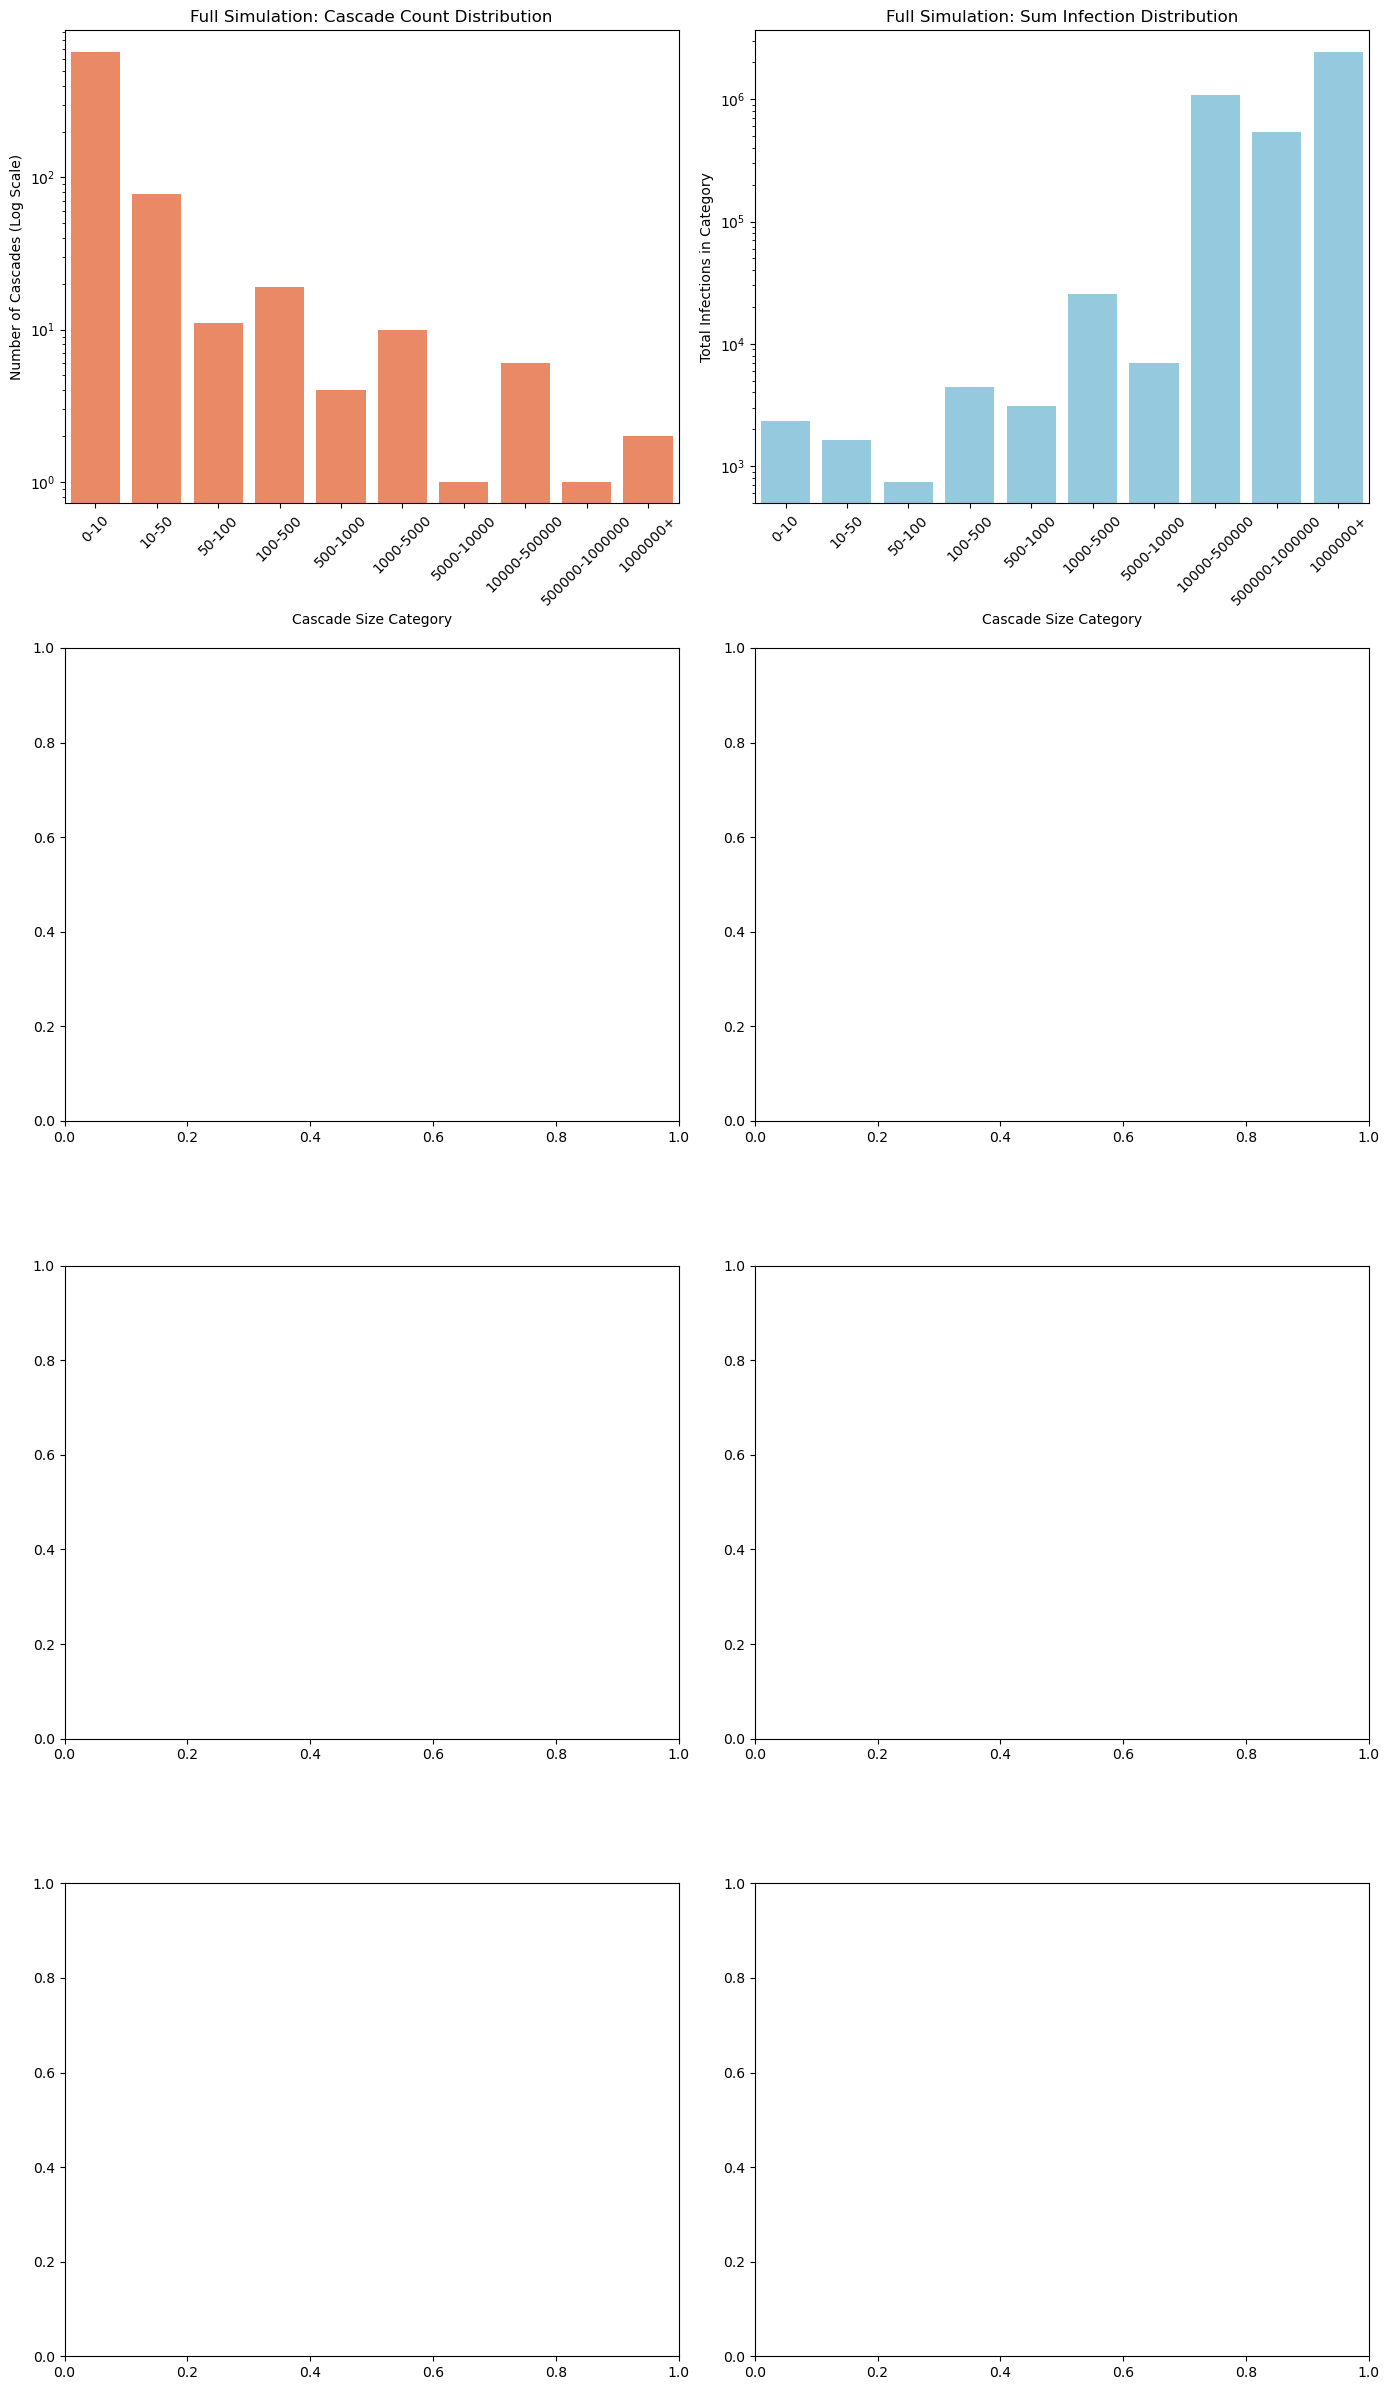

In [83]:
# --- Main Script ---
#if __name__ == '__main__':
#def main():


# All PIDs involved in any transmission event (nodes in the full graph)
all_pids_in_graph = list(G_full.nodes())

full_cascade_components = list(nx.weakly_connected_components(G_full))
full_cascade_sizes = [len(c) for c in full_cascade_components]



#subsample_increments = [1000, 2000, 4000, 8000, 16000] 

# Adjust subsample_increments for small test data if necessary
# This makes the example runnable and meaningful even with few PIDs
if len(all_pids_in_graph) > 0 and len(all_pids_in_graph) < 100: # Heuristic for small test data
    max_pids = len(all_pids_in_graph)
    subsample_increments = [max_pids // 4, max_pids // 2, (3 * max_pids) // 4, max_pids]
    subsample_increments = sorted(list(set(i for i in subsample_increments if i > 0))) # Ensure positive, unique, sorted
    if not subsample_increments and max_pids > 0 : subsample_increments = [max_pids]


num_plots = 2 + len(subsample_increments)
num_cols = 2
num_rows = (num_plots + num_cols - 1) // num_cols # Calculate rows needed

fig, axes = plt.subplots(num_rows, num_cols, figsize=(7 * num_cols, 6 * num_rows), squeeze=False)
axes_flat = axes.flatten() # Flatten for easy iteration


plot_cascade_count_distribution(
    cascade_sizes_list=full_cascade_sizes, 
    title="Full Simulation: Cascade Count Distribution", 
    ax=axes_flat[0]
)


# Plot for the full graph
plot_cascade_distribution(full_cascade_sizes, "Full Simulation: Sum Infection Distribution", axes_flat[1])

    # --- SUBSAMPLING LOOP---

# Ensure ax_idx is managed correctly if subsampling plots are added
# ax_plot_offset = 2 # Start subsampling plots from axes_flat[2]
# for i, n_to_sample in enumerate(subsample_increments):
#     ax_idx = i + ax_plot_offset 
#     if ax_idx >= len(axes_flat): break
#     current_ax = axes_flat[ax_idx]



plt.tight_layout()
plt.show()

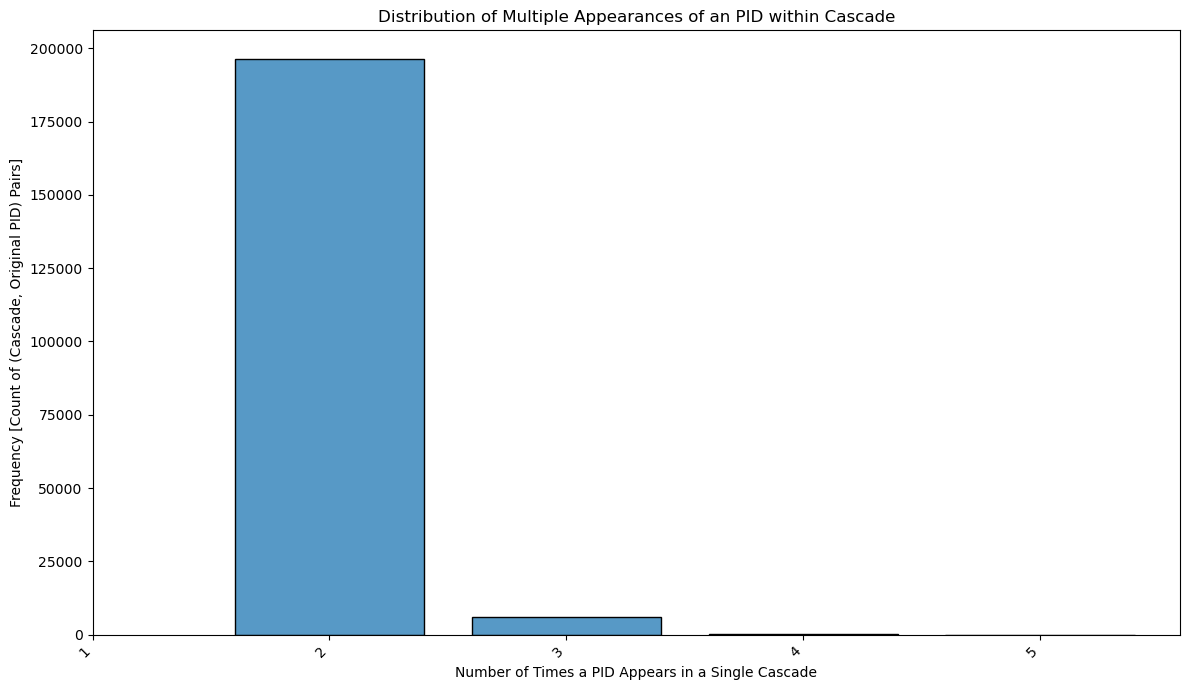

In [86]:
node_to_component_id = {}
for i, component_nodes_set in enumerate(full_cascade_components):
    component_id = i # Or any unique ID you prefer for the component
    for node_alias in component_nodes_set:
        node_to_component_id[node_alias] = component_id

# 3. Map this component ID back to the infection_events_df based on 'alias_pid'
#    Every row's 'alias_pid' is a node in G_full (or should be, if it's an event endpoint).
#    Initialize the 'cascade_id' column, perhaps with a default like -1 or NaN
infection_events_df['cascade_id'] =  np.nan

# Use the .map() method for efficient assignment based on the dictionary
# This will look up each value in 'alias_pid' in the 'node_to_component_id' dictionary
# and assign the corresponding component_id.
# If an alias_pid is not in the map (e.g., isolated nodes not added to G_full, or issues),
# it will result in NaN if the default for .map() is used, or keep -1 if .fillna() is used.
infection_events_df['cascade_id'] = infection_events_df['alias_pid'].map(node_to_component_id)


# Remove rows where cascade_id could not be mapped (should be none if all alias_pid are in G_full)
# Or where original 'pid' might be NaN if that's possible in your data
plot_df = infection_events_df.dropna(subset=['cascade_id', 'pid']) 
if plot_df.empty:
    print("No data to plot after assigning cascade IDs or dropping NaNs.")
else:
    # 3. Group by cascade_id and then count occurrences of original 'pid'
    # Ensure 'pid' column here is the original identifier, not an alias
    pids_in_cascade_counts = plot_df.groupby('cascade_id')['pid'].value_counts().reset_index(name='pid_occurrences_in_cascade')
    #print(pids_in_cascade_counts)

    # 4. Filter for PIDs that appear more than once in any given cascade
    reoccurring_pids_in_cascades = pids_in_cascade_counts[pids_in_cascade_counts['pid_occurrences_in_cascade'] > 1]
    #print(reoccurring_pids_in_cascades)

    if reoccurring_pids_in_cascades.empty:
        print("No original PIDs appear more than once in any single aliased cascade.")
    else:
        # 5. Plot the distribution of these "reoccurrence counts"
        fig, ax = plt.subplots(figsize=(12, 7))
        sns.histplot(data=reoccurring_pids_in_cascades, x='pid_occurrences_in_cascade', 
                     discrete=True,  # Crucial for integer data
                     binwidth=1,     # Makes each integer its own bin center (effectively)
                     shrink=0.8,     # Adds small gaps between bars
                     ax=ax)
        #turn off .5 increment values on x axis
        ax.set_xticks(np.arange(1, reoccurring_pids_in_cascades['pid_occurrences_in_cascade'].max() + 1, 1))
        ax.set_title('Distribution of Multiple Appearances of an PID within Cascade')
        ax.set_xlabel('Number of Times a PID Appears in a Single Cascade')
        ax.set_ylabel('Frequency [Count of (Cascade, Original PID) Pairs]')
        plt.xticks(rotation=45, ha='right')
        plt.tight_layout()
        plt.show()